# 06 · Decision analysis: how many patients should the follow-up program call?
The model ranks discharges by readmission risk. A follow-up program (nurse call, medication review, early appointment) costs money for every patient enrolled, and prevents only some readmissions. This notebook finds the share of discharges worth calling, how sensitive that answer is to the assumptions, and who the policy misses.

Uses the calibrated LightGBM predictions on the **patient-grouped test set** from Step 4.

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROC, FIG, RES = Path("data/processed"), Path("figures"), Path("results")
FIG.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)
BLUE, RED, GREY = "#2a6f97", "#c1666b", "grey"
plt.rcParams["text.parse_math"] = False   # show $ signs literally in titles

pred = pd.read_parquet(PROC / "test_predictions.parquet")
df = pd.read_parquet(PROC / "model_table.parquet")
test_patients = set(pd.read_parquet(PROC / "test_patients.parquet")["patient_nbr"])
test = df[df["patient_nbr"].isin(test_patients)].reset_index(drop=True)

# Step 4 saved predictions in the same row order as the test rows of model_table
assert len(test) == len(pred) and (test["patient_nbr"].values == pred["patient_nbr"].values).all()
assert (test["readmit_30"].values == pred["y_true"].values).all()
test["p_risk"] = pred["p_risk"].values

y, p = test["readmit_30"].to_numpy(), test["p_risk"].to_numpy()
N, BASE = len(y), y.mean()
print(f"Test encounters: {N:,}  Patients: {test['patient_nbr'].nunique():,}  Readmission rate: {BASE:.3f}  Mean predicted risk: {p.mean():.3f}")

Test encounters: 19,773  Patients: 13,998  Readmission rate: 0.113  Mean predicted risk: 0.114


## 1. Assumptions (edit here, everything below updates)
These are planning assumptions, not facts from the data. Section 6 shows how much the answer moves when they change.
- **Cost of one readmission:** about $15,000, rounded from AHRQ's average US readmission cost.
- **Program cost per patient:** a nurse follow-up call, medication review and appointment scheduling.
- **Effect:** the program prevents this share of readmissions among the patients it reaches. Published transitional-care programs range widely, so 20% is a middle assumption.

In [ ]:
COST_READMIT = 15_000     # $ per readmission avoided (payer / health-system view)
COST_PER_PATIENT = 200    # $ per patient enrolled in follow-up
EFFECT = 0.20             # relative reduction in readmission among patients called
PER = 1_000               # report results per 1,000 discharges

## 2. Where the readmissions sit: gains by risk decile

In [ ]:
order = np.argsort(-p, kind="stable")
test["decile"] = pd.Series(np.empty(N, dtype=int))
test.loc[order, "decile"] = (np.arange(N) * 10 // N) + 1      # 1 = highest risk

gains = test.groupby("decile").agg(encounters=("readmit_30", "size"),
                                   readmissions=("readmit_30", "sum"),
                                   readmit_rate=("readmit_30", "mean"),
                                   mean_pred=("p_risk", "mean"))
gains["share_of_all_readmits"] = gains["readmissions"] / y.sum()
gains["cumulative_capture"] = gains["share_of_all_readmits"].cumsum()
gains["lift"] = gains["readmit_rate"] / BASE
gains.round(3)

,encounters,readmissions,readmit_rate,mean_pred,share_of_all_readmits,cumulative_capture,lift
decile,,,,,,,
1,1978,565,0.286,0.284,0.252,0.252,2.517
2,1977,344,0.174,0.178,0.153,0.405,1.533
3,1977,279,0.141,0.141,0.124,0.529,1.244
4,1978,204,0.103,0.118,0.091,0.620,0.909
5,1977,209,0.106,0.101,0.093,0.713,0.932
6,1977,189,0.096,0.088,0.084,0.798,0.842
7,1978,145,0.073,0.076,0.065,0.862,0.646
8,1977,150,0.076,0.065,0.067,0.929,0.669
9,1977,89,0.045,0.054,0.040,0.969,0.397


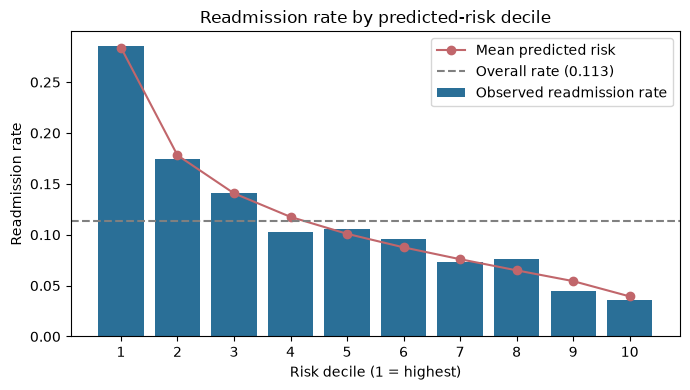

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(gains.index, gains["readmit_rate"], color=BLUE, label="Observed readmission rate")
ax.plot(gains.index, gains["mean_pred"], "o-", color=RED, label="Mean predicted risk")
ax.axhline(BASE, ls="--", color=GREY, label=f"Overall rate ({BASE:.3f})")
ax.set(xlabel="Risk decile (1 = highest)", ylabel="Readmission rate", title="Readmission rate by predicted-risk decile")
ax.set_xticks(range(1, 11)); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "06_gains_by_decile.png", dpi=150); plt.show()

## 3. Cost vs readmissions prevented for every possible call list size
Call the top *k* patients by risk. For each *k*:
- readmissions prevented = EFFECT × readmissions among those called
- net benefit = prevented × COST_READMIT − k × COST_PER_PATIENT

Compared with calling patients at random (no model).

In [ ]:
def policy_curve(y, p, cost_readmit, cost_pp, effect):
    o = np.argsort(-p, kind="stable")
    k = np.arange(1, len(y) + 1)
    reached = np.cumsum(y[o])
    prevented = effect * reached
    out = pd.DataFrame({"share_called": k / len(y), "called": k, "readmits_reached": reached,
                        "precision": reached / k, "recall": reached / y.sum(),
                        "prevented": prevented, "program_cost": k * cost_pp,
                        "savings": prevented * cost_readmit})
    out["net"] = out["savings"] - out["program_cost"]
    out["net_random"] = k * (y.mean() * effect * cost_readmit - cost_pp)
    return out

curve = policy_curve(y, p, COST_READMIT, COST_PER_PATIENT, EFFECT)
best = curve.loc[curve["net"].idxmax()]
call_nobody = best["net"] <= 0
scale = PER / N
print(f"Best share to call: {best['share_called']:.1%}" + ("  (net benefit never positive: call nobody)" if call_nobody else ""))
print(f"Per {PER:,} discharges: call {best['called']*scale:.0f}, prevent {best['prevented']*scale:.1f} readmissions, "
      f"net ${best['net']*scale:,.0f}")
print(f"Calling everyone: net ${curve['net'].iloc[-1]*scale:,.0f} per {PER:,}")

# The curve is flat near its peak, so also report the smallest list that gets 90% of the best net benefit
near = curve[curve["net"] >= 0.9 * best["net"]].iloc[0] if not call_nobody else best
print(f"90% of the best net benefit at {near['share_called']:.1%} called "
      f"({near['called']*scale:.0f} per {PER:,}, prevents {near['prevented']*scale:.1f})")

Best share to call: 78.1%
Per 1,000 discharges: call 781, prevent 20.9 readmissions, net $157,235
Calling everyone: net $140,464 per 1,000
90% of the best net benefit at 48.6% called (486 per 1,000, prevents 15.9)


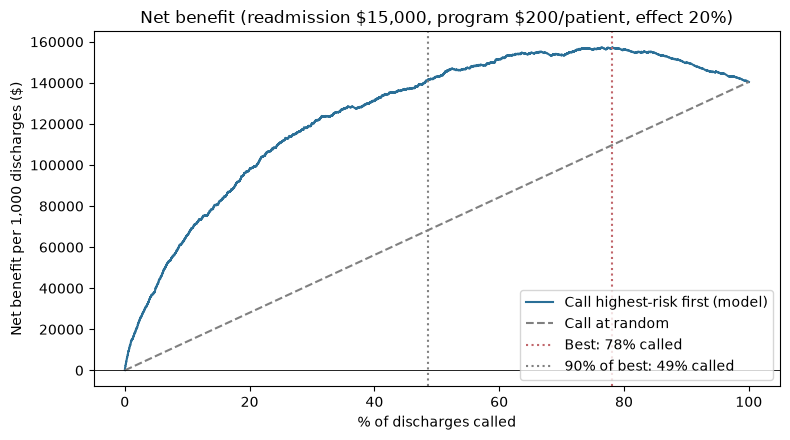

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve["share_called"] * 100, curve["net"] * scale, color=BLUE, label="Call highest-risk first (model)")
ax.plot(curve["share_called"] * 100, curve["net_random"] * scale, ls="--", color=GREY, label="Call at random")
ax.axhline(0, color="black", lw=0.6)
ax.axvline(best["share_called"] * 100, ls=":", color=RED, label=f"Best: {best['share_called']:.0%} called")
ax.axvline(near["share_called"] * 100, ls=":", color=GREY, label=f"90% of best: {near['share_called']:.0%} called")
ax.set(xlabel="% of discharges called", ylabel=f"Net benefit per {PER:,} discharges ($)",
       title=f"Net benefit (readmission ${COST_READMIT:,}, program ${COST_PER_PATIENT}/patient, effect {EFFECT:.0%})")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "06_net_benefit_curve.png", dpi=150); plt.show()

## 4. The same answer from the calibrated probabilities
Calling a patient pays off when expected savings exceed the cost:
`risk × EFFECT × COST_READMIT > COST_PER_PATIENT`, so the break-even risk is `COST_PER_PATIENT / (EFFECT × COST_READMIT)`.
Because Step 4 calibrated the model, this threshold can be applied directly to new patients. If it matches the empirical best above, the calibration is doing its job.

In [ ]:
P_STAR = COST_PER_PATIENT / (EFFECT * COST_READMIT)
share_above = (p >= P_STAR).mean()
print(f"Break-even risk: {P_STAR:.3f}  ->  {share_above:.1%} of discharges are above it")
print(f"Empirical best share: {best['share_called']:.1%}  (risk cut-off there: {np.sort(p)[::-1][int(best['called'])-1]:.3f})")

Break-even risk: 0.067  ->  73.5% of discharges are above it
Empirical best share: 78.1%  (risk cut-off there: 0.062)


## 5. Realistic capacity: what each team size buys
Most follow-up teams can't call half of all discharges. "Calls per readmission prevented" is the number of patients enrolled to stop one readmission.

In [ ]:
def at_share(s):
    r = curve.iloc[max(int(round(s * N)), 1) - 1]
    return {"share_called": s, f"called_per_{PER}": r["called"] * scale,
            f"prevented_per_{PER}": r["prevented"] * scale, "precision": r["precision"], "recall": r["recall"],
            "calls_per_readmit_prevented": 1 / (r["precision"] * EFFECT),
            "cost_per_readmit_prevented": COST_PER_PATIENT / (r["precision"] * EFFECT),
            f"net_per_{PER}": r["net"] * scale,
            f"net_random_per_{PER}": r["net_random"] * scale}

shares = sorted({0.05, 0.10, 0.20, 0.30, 0.50, 1.0, round(float(best["share_called"]), 3),
                 round(float(near["share_called"]), 3)})
capacity = pd.DataFrame([at_share(s) for s in shares]).set_index("share_called")
capacity.round(2)

,called_per_1000,prevented_per_1000,precision,recall,calls_per_readmit_prevented,cost_per_readmit_prevented,net_per_1000,net_random_per_1000
share_called,,,,,,,,
0.050,50.02,3.37,0.34,0.15,14.85,2969.97,40519.90,7025.70
0.100,99.98,5.71,0.29,0.25,17.50,3499.12,65725.99,14044.30
0.200,200.02,9.19,0.23,0.41,21.75,4350.94,97911.29,28095.70
0.300,300.01,12.02,0.20,0.53,24.97,4993.27,120244.78,42139.99
0.486,486.02,15.91,0.16,0.70,30.55,6109.35,141455.52,68267.92
0.500,499.97,16.19,0.16,0.71,30.87,6174.89,142912.05,70228.58
0.781,781.01,20.89,0.13,0.92,37.39,7478.45,157103.12,109704.63
1.000,1000.00,22.70,0.11,1.00,44.06,8811.50,140464.27,140464.27


## 6. Sensitivity: how the best share moves with the assumptions
Each cell is the best share of discharges to call (net benefit per 1,000 in brackets), with readmission cost fixed at $15,000.

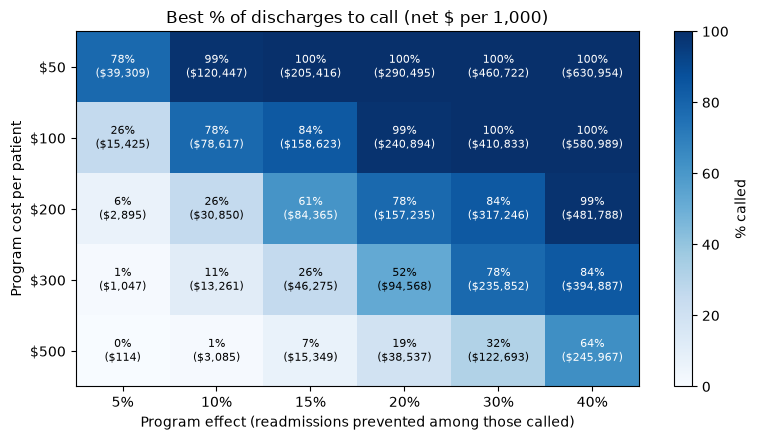

In [ ]:
costs = [50, 100, 200, 300, 500]
effects = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
grid_share = pd.DataFrame(index=costs, columns=effects, dtype=float)
grid_net = grid_share.copy()
for c in costs:
    for e in effects:
        cv = policy_curve(y, p, COST_READMIT, c, e)
        b = cv.loc[cv["net"].idxmax()]
        grid_share.loc[c, e] = b["share_called"] if b["net"] > 0 else 0.0
        grid_net.loc[c, e] = max(b["net"], 0) * scale

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(grid_share.values * 100, cmap="Blues", aspect="auto", vmin=0, vmax=100)
for i, c in enumerate(costs):
    for j, e in enumerate(effects):
        v = grid_share.iloc[i, j] * 100
        ax.text(j, i, f"{v:.0f}%\n(${grid_net.iloc[i, j]:,.0f})", ha="center", va="center", fontsize=8,
                color="white" if v > 55 else "black")
ax.set_xticks(range(len(effects)), [f"{e:.0%}" for e in effects])
ax.set_yticks(range(len(costs)), [f"${c}" for c in costs])
ax.set(xlabel="Program effect (readmissions prevented among those called)", ylabel="Program cost per patient",
       title="Best % of discharges to call (net $ per 1,000)")
fig.colorbar(im, ax=ax, label="% called")
plt.tight_layout(); plt.savefig(FIG / "06_sensitivity_heatmap.png", dpi=150); plt.show()

In [ ]:
prec10 = capacity.loc[0.10, "precision"]
print(f"At 10% capacity, the program breaks even if it prevents at least "
      f"{COST_PER_PATIENT / (prec10 * COST_READMIT):.1%} of readmissions among those called "
      f"(at ${COST_PER_PATIENT}/patient), or if it costs under ${prec10 * EFFECT * COST_READMIT:,.0f} per patient (at {EFFECT:.0%} effect).")

At 10% capacity, the program breaks even if it prevents at least 4.7% of readmissions among those called (at $200/patient), or if it costs under $857 per patient (at 20% effect).


## 7. Uncertainty: bootstrap by patient
The policy (risk cut-off) is fixed; patients are resampled with replacement, keeping each patient's encounters together, to get 95% intervals. This covers sampling noise in the test set only; Section 6 covers uncertainty in the assumptions.

In [ ]:
def bootstrap(cutoff, B=1000, seed=42):
    called = p >= cutoff
    per_pat = pd.DataFrame({"patient_nbr": test["patient_nbr"], "enc": 1,
                            "net": called * (y * EFFECT * COST_READMIT - COST_PER_PATIENT),
                            "prev": called * y * EFFECT}).groupby("patient_nbr").sum()
    arr = per_pat[["enc", "net", "prev"]].to_numpy()
    rng = np.random.default_rng(seed)
    tot = np.vstack([arr[rng.integers(0, len(arr), size=(100, len(arr)))].sum(axis=1)
                     for _ in range(B // 100)])         # B x 3, built in batches to save memory
    net, prev = tot[:, 1] / tot[:, 0] * PER, tot[:, 2] / tot[:, 0] * PER
    return {"net_per_1000": [round(float(x)) for x in np.percentile(net, [2.5, 50, 97.5])],
            "prevented_per_1000": [round(float(x), 2) for x in np.percentile(prev, [2.5, 50, 97.5])],
            "prob_net_positive": round(float((net > 0).mean()), 3)}

cut_best = np.sort(p)[::-1][int(best["called"]) - 1]
cut_10 = np.sort(p)[::-1][int(0.10 * N) - 1]
boot = {"best_policy": bootstrap(cut_best), "top_10pct": bootstrap(cut_10)}
pd.DataFrame(boot).T

,net_per_1000,prevented_per_1000,prob_net_positive
best_policy,"[141688, 156754, 172065]","[19.83, 20.87, 21.89]",1.0
top_10pct,"[56591, 65673, 75304]","[5.03, 5.71, 6.41]",1.0


## 8. Decision curve
Standard clinical view of the same question: net benefit (in readmissions caught, penalising unnecessary calls) across risk cut-offs, compared with calling everyone or no one. The model is worth using wherever its line sits above both.

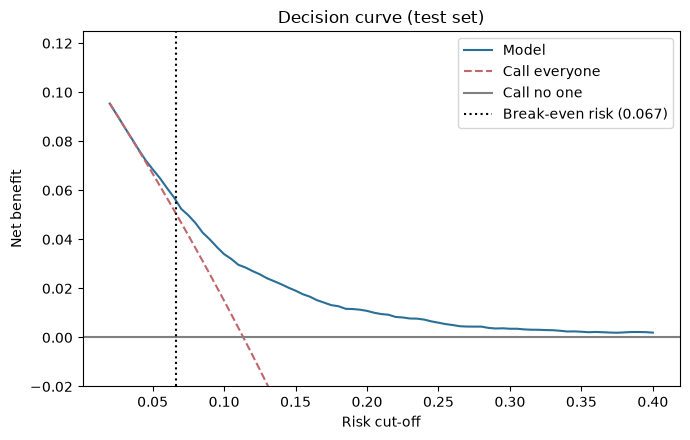

In [ ]:
thr = np.linspace(0.02, 0.40, 77)
def nb_model(t):
    called = p >= t
    tp, fp = (called & (y == 1)).sum() / N, (called & (y == 0)).sum() / N
    return tp - fp * t / (1 - t)
nb = np.array([nb_model(t) for t in thr])
nb_all = BASE - (1 - BASE) * thr / (1 - thr)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr, nb, color=BLUE, label="Model")
ax.plot(thr, nb_all, ls="--", color=RED, label="Call everyone")
ax.axhline(0, color=GREY, label="Call no one")
ax.axvline(P_STAR, ls=":", color="black", label=f"Break-even risk ({P_STAR:.3f})")
ax.set(xlabel="Risk cut-off", ylabel="Net benefit", ylim=(-0.02, BASE * 1.1), title="Decision curve (test set)")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "06_decision_curve.png", dpi=150); plt.show()

## 9. Who the policy misses
Step 5 found the model weakest for patients aged 80+. A single risk ranking may call them less often relative to their readmissions. Checked at both the best policy and a 10% call list.

In [ ]:
groups = {}
if "age_num" in test:                      # Step 2 stores age as a number
    groups["age"] = np.where(test["age_num"] >= 80, "80+", "Under 80")
if "male" in test:                         # Step 2 stores sex as male = 1 / 0
    groups["sex"] = np.where(test["male"] == 1, "Male", "Female")
if "race" in test:
    groups["race"] = test["race"].astype(str).to_numpy()

rows = []
for policy, cut in [("best", cut_best), ("top_10pct", cut_10)]:
    called = p >= cut
    for gcol, g in groups.items():
        for level in pd.unique(g):
            m = g == level
            if m.sum() < 200:          # skip tiny groups
                continue
            yr = y[m]
            rows.append({"policy": policy, "group": gcol, "level": level, "encounters": int(m.sum()),
                         "readmit_rate": yr.mean(), "share_called": called[m].mean(),
                         "recall": (called[m] & (yr == 1)).sum() / max(yr.sum(), 1),
                         "precision": yr[called[m]].mean() if called[m].any() else np.nan})
equity = pd.DataFrame(rows).set_index(["policy", "group", "level"])
equity.round(3)

encounters  readmit_rate  share_called  \
policy    group level                                                     
best      age   Under 80              15942         0.111         0.747   
                80+                    3831         0.122         0.922   
          sex   Male                   9047         0.112         0.771   
                Female                10726         0.114         0.790   
          race  Caucasian             14813         0.117         0.794   
                Unknown                 447         0.072         0.622   
                AfricanAmerican        3697         0.108         0.770   
                Other                   302         0.103         0.699   
                Hispanic                398         0.090         0.686   
top_10pct age   Under 80              15942         0.111         0.102   
                80+                    3831         0.122         0.092   
          sex   Male                   9047         0.112         0.099   
                Female                10726         0.114         0.101   
          race  Caucasian             14813         0.117         0.100   
                Unknown                 447         0.072         0.049   
                AfricanAmerican        3697         0.108         0.111   
                Other                   302         0.103         0.079   
                Hispanic                398         0.090         0.090   

                                 recall  precision  
policy    group level                               
best      age   Under 80          0.907      0.135  
                80+               0.972      0.129  
          sex   Male              0.910      0.133  
                Female            0.929      0.135  
          race  Caucasian         0.921      0.136  
                Unknown           0.812      0.094  
                AfricanAmerican   0.922      0.129  
                Other             0.935      0.137  
                Hispanic          0.972      0.128  
top_10pct age   Under 80          0.272      0.298  
                80+               0.176      0.232  
          sex   Male              0.236      0.269  
                Female            0.265      0.300  
          race  Caucasian         0.258      0.303  
                Unknown           0.094      0.136  
                AfricanAmerican   0.233      0.226  
                Other             0.226      0.292  
                Hispanic          0.361      0.361

## 10. Save results

In [ ]:
results = {
    "assumptions": {"cost_readmit": COST_READMIT, "cost_per_patient": COST_PER_PATIENT, "effect": EFFECT},
    "break_even_risk": round(P_STAR, 4), "share_above_break_even": round(float(share_above), 4),
    "best_share_called": round(float(best["share_called"]), 4), "call_nobody": bool(call_nobody),
    "near_best_share_called": round(float(near["share_called"]), 4),
    "best_per_1000": {"called": round(best["called"] * scale, 1), "prevented": round(best["prevented"] * scale, 2),
                      "net": round(best["net"] * scale)},
    "capacity_table": capacity.round(4).reset_index().to_dict(orient="records"),
    "bootstrap": boot,
    "sensitivity_best_share": {f"${c}": {f"{e:.0%}": round(float(grid_share.loc[c, e]), 3) for e in effects} for c in costs},
}
(RES / "06_decision_metrics.json").write_text(json.dumps(results, indent=2, default=float))
print("Saved results/06_decision_metrics.json")

Saved results/06_decision_metrics.json


## 11. Summary
- **Best share to call:** with $15,000 per readmission, $200 per patient and a 20% effect, net benefit peaks at **78% of discharges** ($157,235 per 1,000 discharges, 20.9 readmissions prevented). The curve is flat near the top: calling **49%** already captures 90% of that benefit ($141,456, 15.9 prevented). Calling everyone earns less ($140,464), because the lowest-risk patients cost more to call than they save.
- **Calibration check:** the break-even risk from the assumptions is 6.7%, which would call 73.5% of patients. The best share found on the data is 78.1% (cut-off 6.2%). They agree, so the calibrated probabilities can be used directly as a decision threshold.
- **Realistic capacity (10%):** 100 calls per 1,000 discharges reach 25% of all readmissions (29% precision) and prevent 5.7, which is 17.5 calls per readmission prevented, or $3,499 of program cost per readmission prevented. Net benefit is $65,726 per 1,000, against about $13,900 for calling the same number at random: 4.7x more. At this size the program still breaks even if it prevents just 4.7% of readmissions, or costs up to $857 per patient.
- **Sensitivity:** the answer depends on the ratio of program cost to effect. A cheap program ($50) should call nearly everyone. An expensive, weak one ($500, 5–15% effect) should call only the top 1–7%. The program has positive net benefit in every scenario tested, because the model lets even small programs target the highest-risk patients first.
- **Bootstrap 95% intervals (by patient):** best policy $141,688–$172,065 per 1,000 (19.8–21.9 readmissions prevented). Top 10%: $56,591–$75,304 (5.0–6.4 prevented). Net benefit was positive in 100% of resamples. This covers sampling noise only. The program's effect is the bigger unknown, which the sensitivity grid addresses.
- **Who the policy misses:** patients aged **80+** are readmitted more often than younger patients (12.2% vs 11.1%), yet a 10% call list calls fewer of them (9.2%) and catches only **17.6%** of their readmissions, against 27.2% for under-80s. This is the same weakness Step 5 found (ROC-AUC 0.601). The gap closes at the best policy (97% vs 91% of readmissions reached), so it matters most for small, realistic programs. A fix would be to reserve part of the capacity for 80+ patients, or to set a lower risk cut-off for that group. On a 10% list, men are caught slightly less often than women (23.6% vs 26.5%) and African American patients slightly less than Caucasian patients (23.3% vs 25.8%). Patients with unknown race are rarely flagged (9.4% recall), but they also have the lowest readmission rate (7.2%) and are a small group (447).